# 인천광역시 관서별 5대 범죄 발생 및 검거 건수 분석

인천광역시 경찰서별 5대 범죄의 발생 건수와 검거 건수를 비교하고, 범죄 유형별 검거 비율 차이를 확인합니다. 포트폴리오에서 바로 확인할 수 있도록 원자료를 노트북 안에 정리했습니다.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']
installed_fonts = {f.name for f in fm.fontManager.ttflist}
for font in font_candidates:
    if font in installed_fonts:
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])

In [2]:
data = pd.DataFrame({
    '구분': ['살인', '살인', '강도', '강도', '강간.강제추행', '강간.강제추행', '절도', '절도', '폭력', '폭력'],
    '발생검거': ['발생', '검거', '발생', '검거', '발생', '검거', '발생', '검거', '발생', '검거'],
    '중부서': [1, 2, 3, 2, 111, 75, 874, 511, 1351, 1096],
    '미추홀서': [7, 4, 11, 8, 253, 220, 1653, 1216, 2298, 2093],
    '남동서': [8, 8, 13, 14, 171, 151, 894, 802, 1377, 1251],
    '부평서': [1, 1, 14, 17, 98, 86, 1089, 780, 1291, 1166],
    '서부서': [5, 4, 3, 3, 238, 199, 1298, 1057, 2718, 2246],
    '계양서': [3, 3, 7, 10, 112, 102, 737, 569, 1293, 1100],
    '강화서': [2, 2, 1, 1, 18, 0, 170, 96, 337, 293],
    '연수서': [5, 4, 5, 4, 124, 100, 1235, 1013, 1440, 1295],
    '삼산서': [3, 3, 3, 3, 184, 163, 1110, 833, 1567, 1399],
    '논현서': [4, 3, 0, 0, 61, 54, 507, 361, 831, 733],
})

data.loc[data['발생검거'] == '폭력', '발생검거'] = '발생'
display(data)

,구분,발생검거,중부서,미추홀서,남동서,부평서,서부서,계양서,강화서,연수서,삼산서,논현서
0,살인,발생,1,7,8,1,5,3,2,5,3,4
1,살인,검거,2,4,8,1,4,3,2,4,3,3
2,강도,발생,3,11,13,14,3,7,1,5,3,0
3,강도,검거,2,8,14,17,3,10,1,4,3,0
4,강간.강제추행,발생,111,253,171,98,238,112,18,124,184,61
5,강간.강제추행,검거,75,220,151,86,199,102,0,100,163,54
6,절도,발생,874,1653,894,1089,1298,737,170,1235,1110,507
7,절도,검거,511,1216,802,780,1057,569,96,1013,833,361
8,폭력,발생,1351,2298,1377,1291,2718,1293,337,1440,1567,831
9,폭력,검거,1096,2093,1251,1166,2246,1100,293,1295,1399,733


In [3]:
data_melted = pd.melt(data, id_vars=['구분', '발생검거'], var_name='경찰서', value_name='건수')
data_pivoted = data_melted.pivot_table(
    index=['구분', '경찰서'],
    columns='발생검거',
    values='건수',
    fill_value=0
).reset_index()
data_pivoted.columns.name = None
data_pivoted = data_pivoted.rename(columns={'발생': '발생 건수', '검거': '검거 건수'})
data_pivoted['검거 비율'] = (data_pivoted['검거 건수'] / data_pivoted['발생 건수']).where(data_pivoted['발생 건수'] != 0)

display(data_pivoted.head())

,구분,경찰서,검거 건수,발생 건수,검거 비율
0,강간.강제추행,강화서,0,18,0.000000
1,강간.강제추행,계양서,102,112,0.910714
2,강간.강제추행,남동서,151,171,0.883041
3,강간.강제추행,논현서,54,61,0.885246
4,강간.강제추행,미추홀서,220,253,0.869565


,발생 건수,검거 건수,검거 비율
count,10.000000,10.000000,10.000000
mean,3.900000,3.400000,0.992143
std,2.378141,1.897367,0.383776
min,1.000000,1.000000,0.571429
25%,2.250000,2.250000,0.800000
50%,3.500000,3.000000,1.000000
75%,5.000000,4.000000,1.000000
max,8.000000,8.000000,2.000000


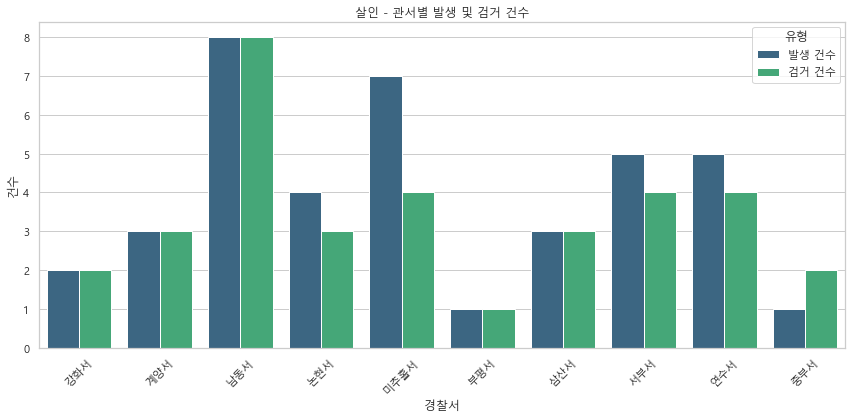

,발생 건수,검거 건수,검거 비율
count,10.000000,10.00000,9.000000
mean,6.000000,6.20000,0.990413
std,5.033223,5.80804,0.239837
min,0.000000,0.00000,0.666667
25%,3.000000,2.25000,0.800000
50%,4.000000,3.50000,1.000000
75%,10.000000,9.50000,1.076923
max,14.000000,17.00000,1.428571


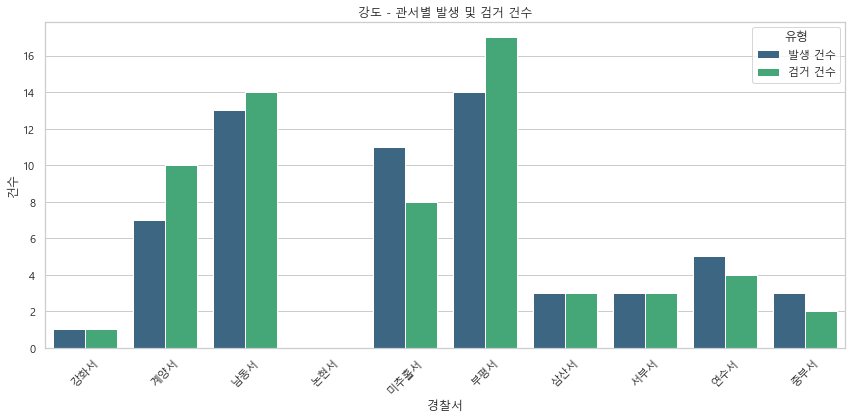

,발생 건수,검거 건수,검거 비율
count,10.000000,10.000000,10.000000
mean,137.000000,115.000000,0.763025
std,74.498322,67.874066,0.276442
min,18.000000,0.000000,0.000000
25%,101.250000,77.750000,0.813872
50%,118.000000,101.000000,0.873558
75%,180.750000,160.000000,0.884695
max,253.000000,220.000000,0.910714


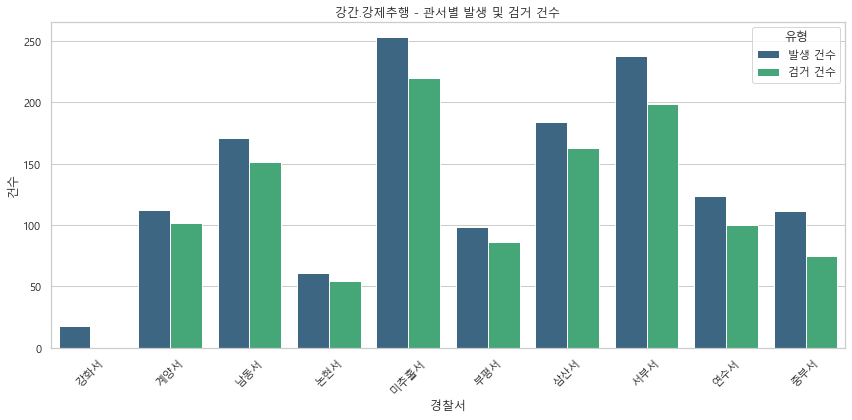

,발생 건수,검거 건수,검거 비율
count,10.000000,10.000000,10.000000
mean,956.700000,723.800000,0.736745
std,421.629129,342.072377,0.102140
min,170.000000,96.000000,0.564706
25%,771.250000,525.500000,0.713087
50%,991.500000,791.000000,0.743041
75%,1203.750000,968.000000,0.803760
max,1653.000000,1216.000000,0.897092


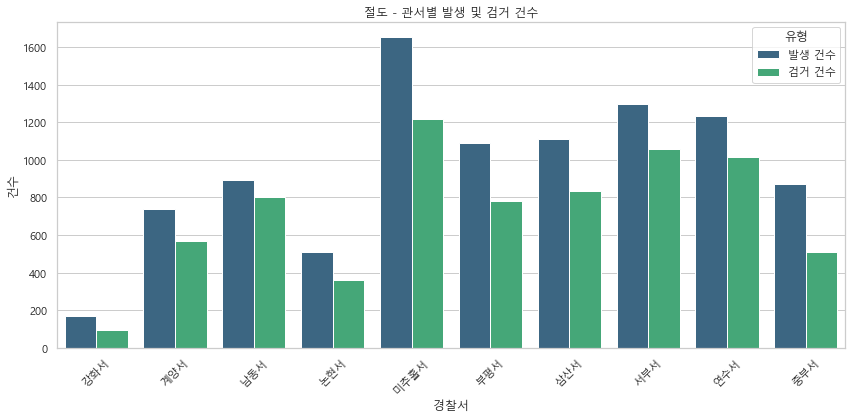

,발생 건수,검거 건수,검거 비율
count,10.000000,10.000000,10.000000
mean,1450.300000,1267.200000,0.875439
std,668.971524,573.521636,0.035282
min,337.000000,293.000000,0.811251
25%,1291.500000,1097.000000,0.855410
50%,1364.000000,1208.500000,0.887429
75%,1535.250000,1373.000000,0.902208
max,2718.000000,2246.000000,0.910792


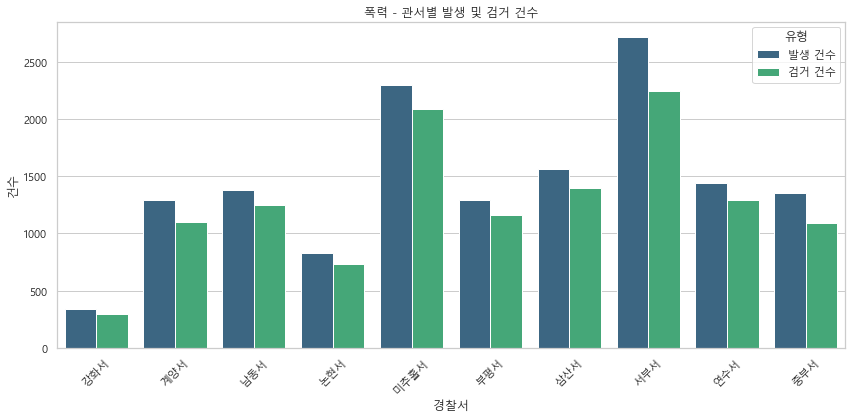

In [4]:
def plot_crime_type(crime_type):
    filtered = data_pivoted[data_pivoted['구분'] == crime_type]
    display(filtered[['경찰서', '발생 건수', '검거 건수', '검거 비율']].describe())

    plot_data = filtered.melt(
        id_vars=['경찰서'],
        value_vars=['발생 건수', '검거 건수'],
        var_name='유형',
        value_name='건수'
    )

    plt.figure(figsize=(12, 6))
    sns.barplot(data=plot_data, x='경찰서', y='건수', hue='유형', palette='viridis')
    plt.title(f'{crime_type} - 관서별 발생 및 검거 건수')
    plt.xlabel('경찰서')
    plt.ylabel('건수')
    plt.xticks(rotation=45)
    plt.legend(title='유형')
    plt.tight_layout()
    plt.show()

for crime_type in ['살인', '강도', '강간.강제추행', '절도', '폭력']:
    plot_crime_type(crime_type)

,범죄 유형,가장 높은 검거 비율 경찰서,가장 낮은 검거 비율 경찰서,가장 높은 검거 비율,가장 낮은 검거 비율
0,강간.강제추행,계양서,강화서,0.910714,0.000000
1,강도,계양서,중부서,1.428571,0.666667
2,살인,중부서,미추홀서,2.000000,0.571429
3,절도,남동서,강화서,0.897092,0.564706
4,폭력,미추홀서,중부서,0.910792,0.811251


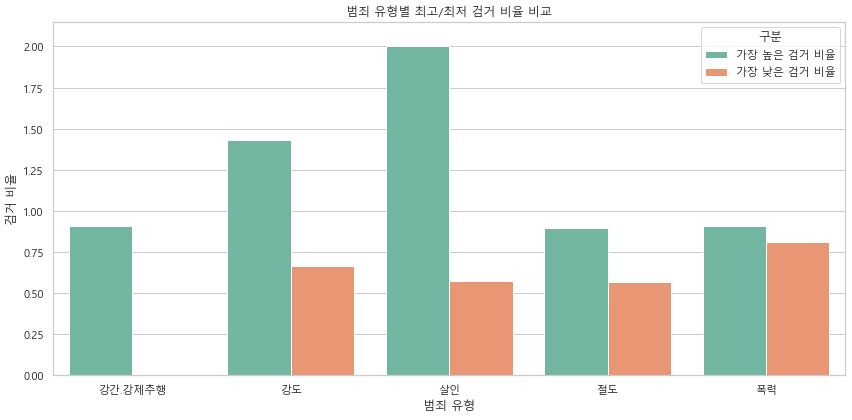

In [5]:
ratio_summary = []
for crime_type, group in data_pivoted.groupby('구분'):
    ratio_summary.append({
        '범죄 유형': crime_type,
        '가장 높은 검거 비율 경찰서': group.loc[group['검거 비율'].idxmax(), '경찰서'],
        '가장 낮은 검거 비율 경찰서': group.loc[group['검거 비율'].idxmin(), '경찰서'],
        '가장 높은 검거 비율': group['검거 비율'].max(),
        '가장 낮은 검거 비율': group['검거 비율'].min(),
    })

ratio_summary = pd.DataFrame(ratio_summary)
display(ratio_summary)

ratio_plot_data = ratio_summary.melt(
    id_vars=['범죄 유형'],
    value_vars=['가장 높은 검거 비율', '가장 낮은 검거 비율'],
    var_name='구분',
    value_name='검거 비율'
)

plt.figure(figsize=(12, 6))
sns.barplot(data=ratio_plot_data, x='범죄 유형', y='검거 비율', hue='구분', palette='Set2')
plt.title('범죄 유형별 최고/최저 검거 비율 비교')
plt.xlabel('범죄 유형')
plt.ylabel('검거 비율')
plt.ylim(0, max(1.1, ratio_plot_data['검거 비율'].max() + 0.15))
plt.tight_layout()
plt.show()